In [1]:
import sys
import os
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), ".")))

from src.preprocess.preprocess import DataPreprocessor
from src.features.features import FeatureEngineer
from src.pipeline.BasePipeline import BasePipeline

# 1. NẠP VÀ LÀM SẠCH DỮ LIỆU
print(">>> [Data] Đang xử lý tập Train và Test...")
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

X_train_raw = df_train.drop(columns=["SalePrice", "Id"])
y_train_raw = df_train["SalePrice"]
X_test_raw = df_test.drop(columns=["Id"])
test_ids = df_test["Id"]

# Log-transform target để giảm ảnh hưởng outliers
y_train = np.log1p(y_train_raw)

preprocessor = DataPreprocessor()
X_train_clean = preprocessor.process(X_train_raw, is_train=True)
X_test_clean = preprocessor.process(X_test_raw, is_train=False)

fe = FeatureEngineer()
X_train_final = fe.create_features(X_train_clean)
X_test_final = fe.create_features(X_test_clean)

# 2. KHAI BÁO MÔ HÌNH XGBOOST 
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# 3. CHẠY K-FOLD (5 FOLDS) 
pipeline = BasePipeline(model_name="XGBoost", model_instance=xgb_model, n_splits=5)

oof_preds, final_test_preds_log = pipeline.fit_predict_kfold(
    X=X_train_final, y=y_train, test_data=X_test_final
)

final_test_preds = np.expm1(final_test_preds_log)
os.makedirs("reports", exist_ok=True)
submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_test_preds})
submission.to_csv("reports/submission_version3.csv", index=False)

>>> [Data] Đang xử lý tập Train và Test...
>>> [Preprocess] Bắt đầu làm sạch dữ liệu...
>>> [Preprocess] Đang học bộ mã hóa từ tập Train...
>>> [Preprocess] Đang chuyển đổi dữ liệu Chữ thành Số...
>>> [Preprocess] Hoàn thành!
>>> [Preprocess] Bắt đầu làm sạch dữ liệu...
>>> [Preprocess] Đang chuyển đổi dữ liệu Chữ thành Số...
>>> [Preprocess] Hoàn thành!
>>> [Feature Engineering] Bắt đầu tạo các biến số mới...
>>> [Feature Engineering] Hoàn thành! Dữ liệu hiện có 84 cột.
>>> [Feature Engineering] Bắt đầu tạo các biến số mới...
>>> [Feature Engineering] Hoàn thành! Dữ liệu hiện có 84 cột.
========== ĐANG CHẠY PIPELINE: XGBoost (5 Folds) ==========

--- Đang huấn luyện XGBoost - Fold 0 ---
> Điểm Fold 0: R2 = 0.9043 | MAE = 0.09

--- Đang huấn luyện XGBoost - Fold 1 ---
> Điểm Fold 1: R2 = 0.9141 | MAE = 0.08

--- Đang huấn luyện XGBoost - Fold 2 ---
> Điểm Fold 2: R2 = 0.8165 | MAE = 0.09

--- Đang huấn luyện XGBoost - Fold 3 ---
> Điểm Fold 3: R2 = 0.9163 | MAE = 0.08

--- Đang huấn lu

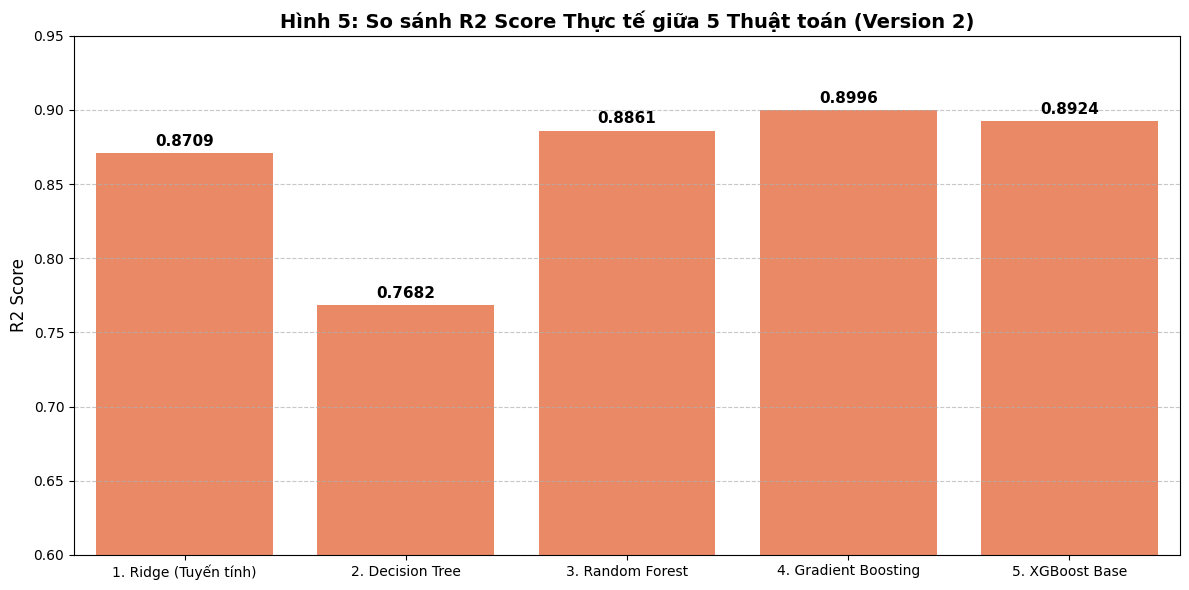

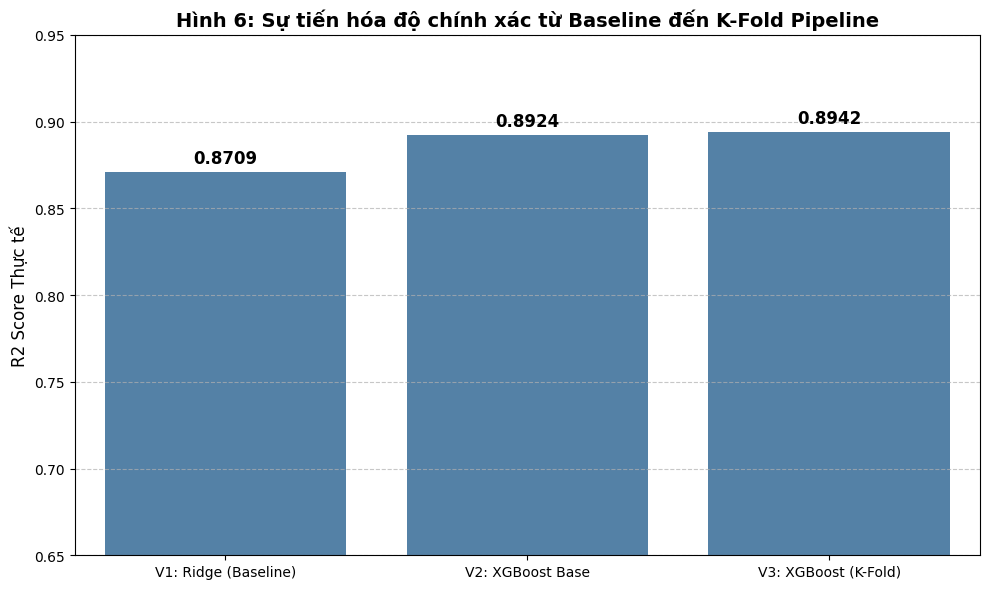

 - V1 Ridge: 0.8709
 - V2 XGBoost Base: 0.8924
 - V3 K-Fold: 0.8942


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

#  Chia 80/20
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42
)

models_v2 = {
    "1. Ridge (Tuyến tính)": Ridge(alpha=10),
    "2. Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "3. Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "4. Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, random_state=42
    ),
    "5. XGBoost Base": XGBRegressor(
        n_estimators=100, learning_rate=0.1, random_state=42
    ),
}

v2_scores = {}
for name, model in models_v2.items():
    model.fit(X_tr, y_tr)
    v2_scores[name] = r2_score(y_val, model.predict(X_val))
# Hinh 5
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(x=list(v2_scores.keys()), y=list(v2_scores.values()), color="coral")
for i, v in enumerate(v2_scores.values()):
    ax1.text(
        i,
        v + 0.005,
        f"{v:.4f}",
        color="black",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )

plt.ylim(0.60, 0.95)
plt.title(
    "Hình 5: So sánh R2 Score Thực tế giữa 5 Thuật toán",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("R2 Score", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("reports/03_model_comparison_v2.png", dpi=300)
plt.show()

# Hinh 6
r2_kfold = r2_score(y_train, oof_preds)

evolution_stages = ["V1: Ridge (Baseline)", "V2: XGBoost Base", "V3: XGBoost (K-Fold)"]
evolution_scores = [
    v2_scores["1. Ridge (Tuyến tính)"],
    v2_scores["5. XGBoost Base"],
    r2_kfold,
]

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x=evolution_stages, y=evolution_scores, color="steelblue")
for i, v in enumerate(evolution_scores):
    ax2.text(
        i,
        v + 0.005,
        f"{v:.4f}",
        color="black",
        ha="center",
        fontweight="bold",
        fontsize=12,
    )

plt.ylim(0.65, 0.95)
plt.title(
    "Hình 6: Sự tiến hóa độ chính xác từ Baseline đến K-Fold Pipeline",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("R2 Score Thực tế", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("reports/03_model_comparison.png", dpi=300)
plt.show()
print(f" - V1 Ridge: {evolution_scores[0]:.4f}")
print(f" - V2 XGBoost Base: {evolution_scores[1]:.4f}")
print(f" - V3 K-Fold: {evolution_scores[2]:.4f}")